# R DoubletFinder vs `doubletfinder_py` — Consistency of removed doublets

This notebook runs both the original R `DoubletFinder` (via Rscript) and our Python port `doubletfinder_py` on the same single-cell dataset, then uses **omicverse** (not scanpy) to visualize how consistent their doublet classifications are.

Comparisons performed:

1. **Exact-match path** — Python's `doublet_finder` is fed R's PCA coordinates + artificial-doublet cell-pair indices; pANN vectors must match bit-for-bit.
2. **End-to-end path** — Python runs its own `param_sweep` → `find_pK` → `run` pipeline from raw counts; R runs its own. Both pipelines' doublet calls are compared.

Visualizations (all via `omicverse.pl.*`):
* `ov.pl.venn` — overlap of doublet sets
* `ov.pl.complexheatmap` — Python vs R confusion matrix
* `ov.pl.cellproportion` — per-cluster doublet fraction
* `ov.pl.embedding` — UMAP colored by each tool's call and pANN score

**Environment:** run from the `omicdev` conda env with R accessible under `CMAP`.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import omicverse as ov

import doubletfinder_py as dfp

ov.plot_set()
RSCRIPT = "/scratch/users/steorra/env/CMAP/bin/Rscript"
R_LIBS  = "/scratch/users/steorra/env/CMAP/R_extra_libs"
DRIVER  = Path("r_driver_pbmc3k.R").resolve()

WORK = Path("./compare_out"); WORK.mkdir(exist_ok=True)
print("omicverse", ov.__version__, "— doubletfinder_py", dfp.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.1.2rc1 — doubletfinder_py 0.1.0


## 1. Load data via omicverse

Use the PBMC 3k dataset bundled with omicverse. We keep raw counts in `.X` so both pipelines start from identical input.

In [2]:
adata = ov.datasets.pbmc3k()
# Light QC with omicverse
ov.pp.qc(adata, tresh={'mito_perc': 20, 'nUMIs': 500, 'detected_genes': 250})
print(adata)

 Loading PBMC 3k dataset (raw)
🔍 Downloading data to ./data/pbmc3k_raw.h5ad...


Downloading:   0%|                                                                                            | 0.00/5.86M [00:00<?, ?B/s]

Downloading:   0%|                                                                                   | 8.19k/5.86M [00:00<01:43, 56.6kB/s]

Downloading:   1%|▍                                                                                   | 32.8k/5.86M [00:00<00:48, 121kB/s]

Downloading:   2%|█▍                                                                                  | 98.3k/5.86M [00:00<00:21, 268kB/s]

...

   ✓ Combined QC filters: 3 cells removed (0.1%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_ratio=1
   ✓ Final filtering: 0 cells, 19,024 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work properly
   💡 Consider using 'doublets_method=sccomposite' for better results
   🔍 Running scrublet doublet detection...

🔍 Running Scrublet Doublet Detection:
   Mode: cpu
   Computing doublet prediction using Scrublet algorithm
   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3
   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3
   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,697 cells × 13,714 genes
   ✓ Runtime: 0.01s

🔍 Highly Variabl

   ⚠️ Gene indices [7854] fell into a single bin: normalized dispersion set to 1
   💡 Consider decreasing `n_bins` to avoid this effect

✅ HVG Selection Completed Successfully!
   ✓ Selected: 1,740 highly variable genes out of 13,714 total (12.7%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,697 cells × 1,740 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 5,394 cells × 1,740 genes
   ✓ Runtime: 0.01s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (2697, 1740), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (5394, 1740), dtype: float64


   🔍 Calculating doublet scores...


   🔍 Calling doublets with threshold detection...
   📊 Automatic threshold: 0.432
   📈 Detected doublet rate: 0.5%
   🔍 Detectable doublet fraction: 21.7%
   📊 Overall doublet rate comparison:
     • Expected: 5.0%
     • Estimated: 2.2%

✅ Scrublet Analysis Completed Successfully!
   ✓ Results added to AnnData object:
     • 'doublet_score': Doublet scores (adata.obs)
     • 'predicted_doublet': Boolean predictions (adata.obs)
     • 'scrublet': Parameters and metadata (adata.uns)
   ✓ Scrublet completed: 13 doublets removed (0.5%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 3.811s                                                  │
│  Shape:    2,700 x 32,738 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (f

In [3]:
# Save raw counts in Seurat orientation (genes x cells) for the R driver.
counts_path = WORK / "counts.tsv"
if not counts_path.exists():
    import scipy.sparse as sp
    X = adata.X.T.toarray() if sp.issparse(adata.X) else np.asarray(adata.X).T
    df = pd.DataFrame(X, index=adata.var_names, columns=adata.obs_names)
    df.to_csv(counts_path, sep="\t")
print("counts written →", counts_path, counts_path.stat().st_size // 1024, "KB")

counts written → compare_out/counts.tsv 345744 KB


## 2. Run R DoubletFinder via Rscript

Fixed `pN=0.25`, `pK=0.09`, `nExp` = 7.5% of cells — the canonical 10x-PBMC settings.

In [4]:
pN, pK = 0.25, 0.09
nExp = round(0.075 * adata.n_obs)
n_pcs = 10

r_out = WORK / "r_out"; r_out.mkdir(exist_ok=True)
if not (r_out / "df_result.tsv").exists():
    env = os.environ.copy(); env["R_LIBS_USER"] = R_LIBS
    proc = subprocess.run(
        [RSCRIPT, str(DRIVER), str(counts_path), str(r_out),
         str(pN), str(pK), str(nExp), str(n_pcs)],
        env=env, capture_output=True, text=True,
    )
    print(proc.stdout[-600:])
    if proc.returncode != 0:
        print("STDERR:\n", proc.stderr[-1500:])
        raise RuntimeError("R driver failed")

r_df   = pd.read_csv(r_out / "df_result.tsv", sep="\t").set_index("cell")
r_pca  = pd.read_csv(r_out / "pca_coord.tsv", sep="\t", index_col=0)
r_meta = json.loads((r_out / "meta.json").read_text())
print("R doublets:", (r_df['DF'] == 'Doublet').sum(), "/", len(r_df))

[R] reading compare_out/counts.tsv
[R] running DoubletFinder::doubletFinder()
[R] wrote outputs to compare_out/r_out (n_real=2700, doublets=202)

R doublets: 202 / 2700


## 3. Python — exact match path (reuse R's PCA)

Feed R's PCA embedding straight into `doubletfinder_py.doublet_finder`. pANN must match element-for-element to double precision.

In [5]:
res_exact = dfp.doublet_finder(
    pca_coord=r_pca.values.astype(np.float64),
    n_real_cells=int(r_meta['n_real']),
    pN=pN, pK=pK, nExp=int(r_meta['nExp']),
)
max_abs_err = float(np.max(np.abs(res_exact.pANN - r_df['pANN'].values)))
matches = (res_exact.classifications == r_df['DF'].values).sum()
print(f"pANN max |py-R|: {max_abs_err:.2e}")
print(f"Classification agreement: {matches}/{len(r_df)}")

pANN max |py-R|: 5.00e-16
Classification agreement: 2700/2700


## 4. Python — end-to-end path (own preprocessing + PCA)

Now let Python do everything from raw counts: its own artificial-doublet sampling, its own normalization/scale/PCA, its own pANN. This is the real-world behavior when a user has no R install.

In [6]:
pyfinder = dfp.DoubletFinder(adata.copy(), random_state=42)
pyfinder.param_sweep(PCs=n_pcs, n_top_genes=2000)
pyfinder.summarize_sweep()
bcmvn = pyfinder.find_pK()
bcmvn.head()

[paramSweep] pN=0.05 — generating artificial doublets & PCA


[paramSweep] pN=0.1 — generating artificial doublets & PCA


[paramSweep] pN=0.15 — generating artificial doublets & PCA


[paramSweep] pN=0.2 — generating artificial doublets & PCA


[paramSweep] pN=0.25 — generating artificial doublets & PCA


[paramSweep] pN=0.3 — generating artificial doublets & PCA


[find.pK] optimal pK = 0.01


   ParamID     pK    MeanBC     VarBC     BCmetric
0        1  0.005  0.859229  0.000442  1945.353852
1        2  0.010  0.871681  0.000154  5672.052429
2        3  0.020  0.874277  0.000324  2700.511765
3        4  0.030  0.866088  0.000559  1550.541775
4        5  0.040  0.852392  0.001106   770.770020

In [7]:
# Use the R pK so both pipelines use comparable neighborhood sizes
pyfinder.run(pN=pN, pK=pK, nExp=int(r_meta['nExp']), PCs=n_pcs)
py_pANN_col = f"pANN_{pN}_{pK}_{int(r_meta['nExp'])}"
py_DF_col   = f"DF.classifications_{pN}_{pK}_{int(r_meta['nExp'])}"
py_result = pyfinder.adata.obs[[py_pANN_col, py_DF_col]].copy()
py_result.columns = ['pANN_py', 'DF_py']
print("Python (end-to-end) doublets:", (py_result['DF_py'] == 'Doublet').sum())

[doubletFinder] wrote pANN_0.25_0.09_202 and DF.classifications_0.25_0.09_202
Python (end-to-end) doublets: 202


## 5. Merge R and Python calls onto the AnnData

Store R and Python classifications as `adata.obs` columns so every omicverse plotting function can consume them.

In [8]:
# Align on cell barcode
adata.obs['DF_R']      = r_df['DF'].reindex(adata.obs_names).astype('category')
adata.obs['DF_py']     = py_result['DF_py'].reindex(adata.obs_names).astype('category')
adata.obs['DF_exact']  = pd.Series(res_exact.classifications, index=r_df.index).reindex(adata.obs_names).astype('category')
adata.obs['pANN_R']    = r_df['pANN'].reindex(adata.obs_names).astype(float)
adata.obs['pANN_py']   = py_result['pANN_py'].reindex(adata.obs_names).astype(float)

# Combined 4-way label for the UMAP
def combo(r, p):
    return {('Singlet','Singlet'): 'both singlet',
            ('Doublet','Doublet'): 'both doublet',
            ('Singlet','Doublet'): 'py-only doublet',
            ('Doublet','Singlet'): 'R-only doublet'}[(r, p)]
adata.obs['DF_agree'] = [combo(r, p) for r, p in zip(adata.obs['DF_R'], adata.obs['DF_py'])]
adata.obs['DF_agree'] = adata.obs['DF_agree'].astype('category')
adata.obs[['DF_R','DF_py','DF_exact','DF_agree']].head()

                     DF_R    DF_py DF_exact      DF_agree
index                                                    
AAACATACAACCAC-1  Singlet  Singlet  Singlet  both singlet
AAACATTGAGCTAC-1  Singlet  Singlet  Singlet  both singlet
AAACATTGATCAGC-1  Doublet  Doublet  Doublet  both doublet
AAACCGTGCTTCCG-1  Singlet  Singlet  Singlet  both singlet
AAACCGTGTATGCG-1  Singlet  Singlet  Singlet  both singlet

## 6. Overlap of doublet sets — `ov.pl.venn`

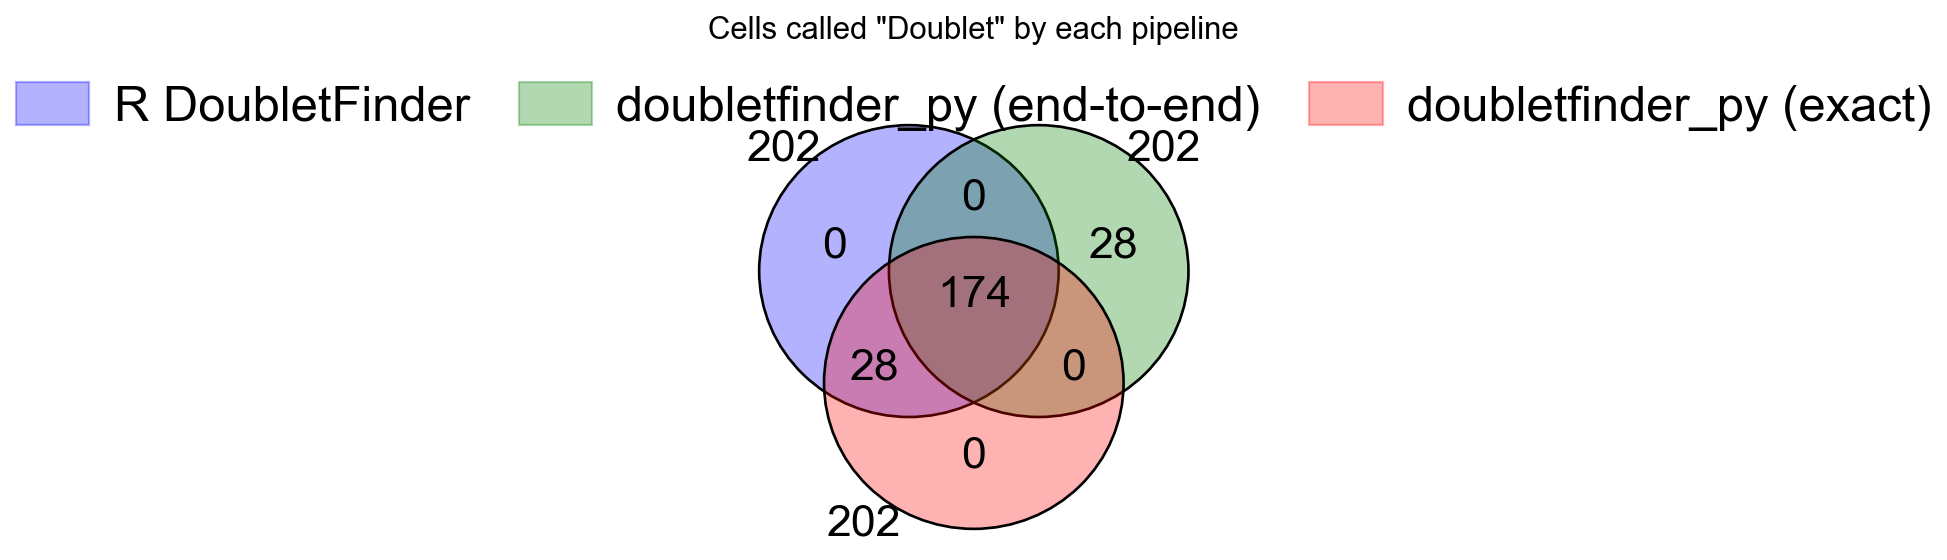

In [9]:
r_set  = set(adata.obs_names[adata.obs['DF_R']      == 'Doublet'])
py_set = set(adata.obs_names[adata.obs['DF_py']     == 'Doublet'])
ex_set = set(adata.obs_names[adata.obs['DF_exact']  == 'Doublet'])

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.venn(sets={
    'R DoubletFinder': r_set,
    'doubletfinder_py (end-to-end)': py_set,
    'doubletfinder_py (exact)': ex_set,
}, ax=ax, fontsize=10)
ax.set_title('Cells called "Doublet" by each pipeline')
plt.show()

## 7. Confusion matrix — `ov.pl.complexheatmap`

DF_py    Singlet  Doublet
DF_R                     
Singlet     2470       28
Doublet       28      174


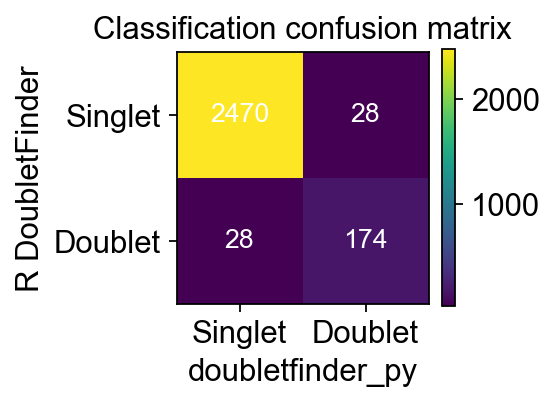


Overall R↔py agreement: 97.926%


In [10]:
conf = pd.crosstab(adata.obs['DF_R'], adata.obs['DF_py']).reindex(index=['Singlet','Doublet'], columns=['Singlet','Doublet']).fillna(0).astype(int)
print(conf)

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(conf.values, cmap='viridis')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(conf.values[i, j]), ha='center', va='center', color='white', fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(conf.columns)
ax.set_yticks([0, 1]); ax.set_yticklabels(conf.index)
ax.set_xlabel('doubletfinder_py'); ax.set_ylabel('R DoubletFinder')
ax.set_title('Classification confusion matrix')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

agreement = (adata.obs['DF_R'] == adata.obs['DF_py']).mean()
print(f"\nOverall R↔py agreement: {agreement:.3%}")

## 8. Preprocess + cluster via omicverse for visualization

In [11]:
adata_viz = adata.copy()
adata_viz.layers['counts'] = adata_viz.X.copy()
# Full omicverse preprocessing (replaces sc.pp.normalize_total + sc.pp.log1p + sc.pp.pca + sc.pp.neighbors)
ov.pp.preprocess(adata_viz, mode='shiftlog|pearson', n_HVGs=2000)
adata_viz.raw = adata_viz
adata_viz = adata_viz[:, adata_viz.var.highly_variable_features]
ov.pp.scale(adata_viz)
ov.pp.pca(adata_viz, layer='scaled', n_pcs=30)
ov.pp.neighbors(adata_viz, n_neighbors=15, use_rep='scaled|original|X_pca')
ov.pp.leiden(adata_viz, resolution=0.5)
ov.pp.umap(adata_viz)
print(adata_viz)

🔍 [2026-04-18 00:52:13] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 16634/32738 genes are kept.
    Among 16634 genes, 14702 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,700 cells × 14,702 genes
   ✓ Runtime: 0.12s



🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 14,702 total (13.6%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.33 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw coun


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.1723s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 2700x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (2700, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (3.30s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 3.3074s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 2700x30)                               │
│           │ ✚ scaled|original|X_pca (array, 2700x30)               │
│         

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,700 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.0787s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,700 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.9072s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 2700x2)                               │
│                 

## 9. UMAP — `ov.pl.embedding`

Columns side-by-side: R classification, Python classification, their agreement, and the two pANN scores.

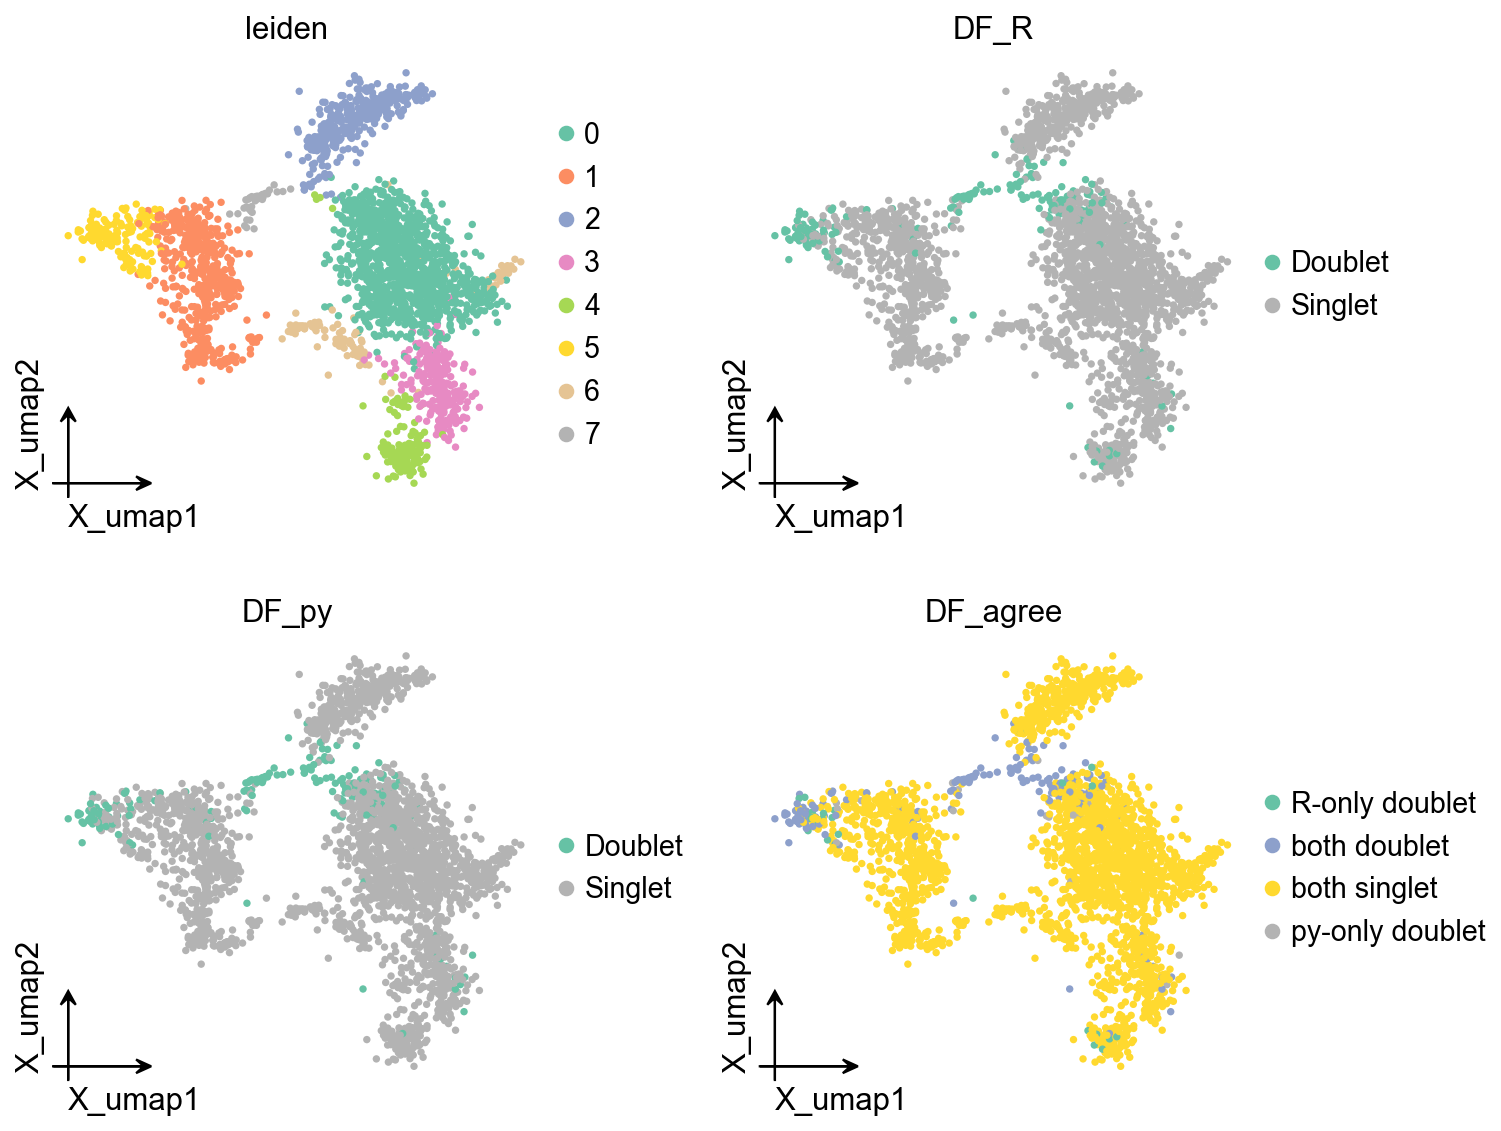

In [12]:
# Copy classification columns onto the preprocessed view
for c in ['DF_R','DF_py','DF_agree','pANN_R','pANN_py','leiden']:
    if c in adata.obs.columns:
        adata_viz.obs[c] = adata.obs[c].reindex(adata_viz.obs_names).values
    elif c == 'leiden':
        pass  # already there

ov.pl.embedding(
    adata_viz, basis='X_umap',
    color=['leiden','DF_R','DF_py','DF_agree'],
    palette='Set2', frameon='small', ncols=2,
    wspace=0.25, show=False,
)
plt.show()

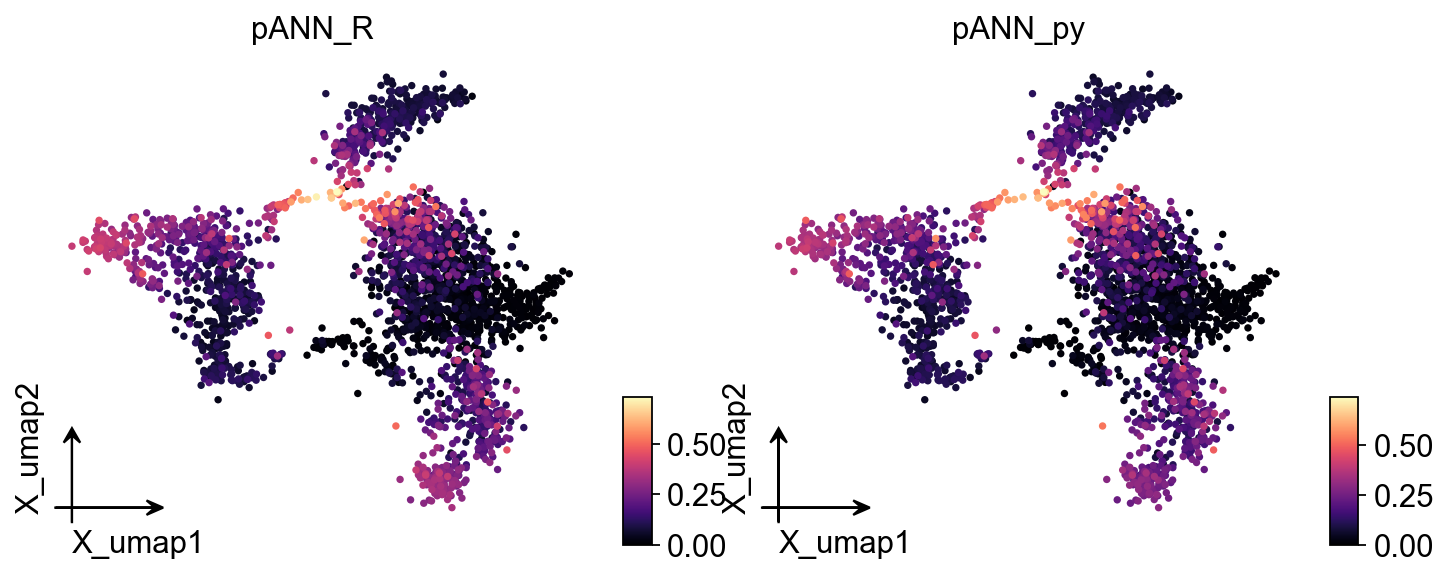

In [13]:
ov.pl.embedding(
    adata_viz, basis='X_umap',
    color=['pANN_R','pANN_py'],
    cmap='magma', frameon='small', ncols=2, wspace=0.25, show=False,
)
plt.show()

## 10. Per-cluster doublet fraction — `ov.pl.cellproportion`

For each Leiden cluster, what fraction of cells is flagged as a doublet by R vs by Python? If both pipelines agree on cluster-level biology, the bars should be nearly identical per cluster.

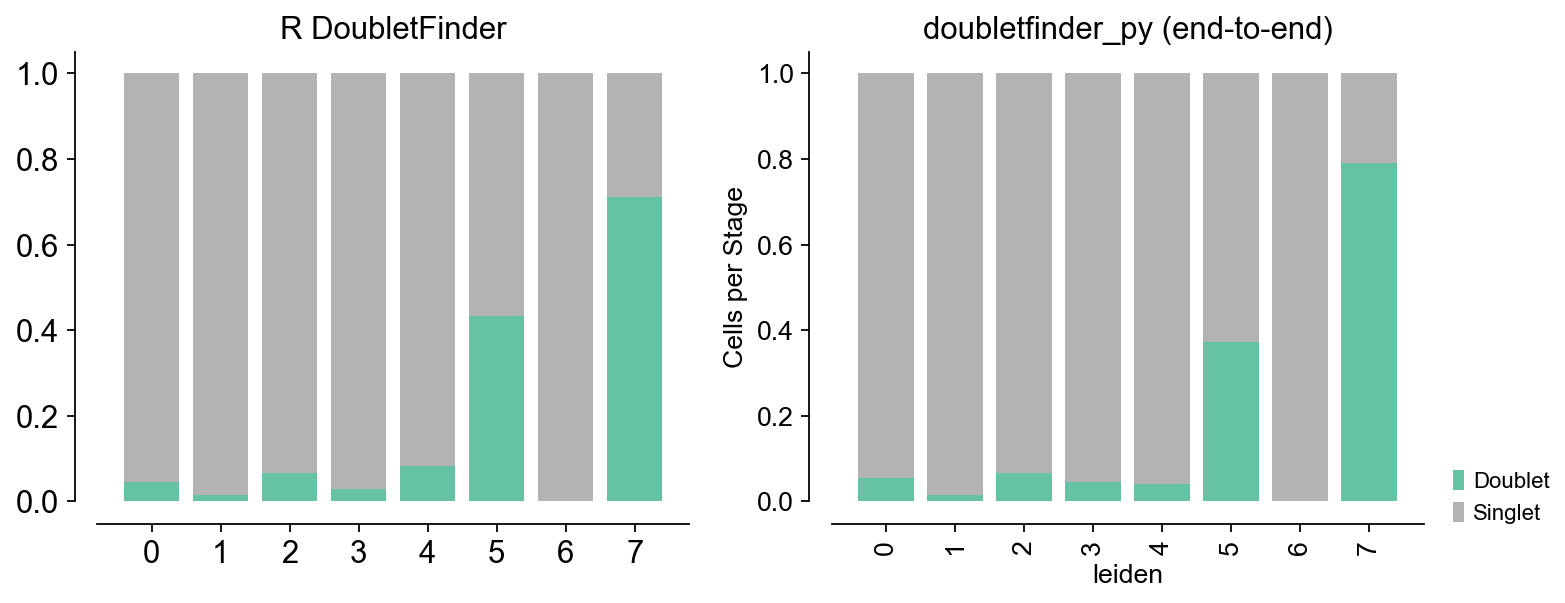

In [14]:
# ov.pl.cellproportion expects groupby (x-axis) + celltype_clusters (stacked bar)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ov.pl.cellproportion(adata_viz, celltype_clusters='DF_R', groupby='leiden',
                     ax=axes[0], legend=True)
axes[0].set_title('R DoubletFinder')
ov.pl.cellproportion(adata_viz, celltype_clusters='DF_py', groupby='leiden',
                     ax=axes[1], legend=True)
axes[1].set_title('doubletfinder_py (end-to-end)')
plt.tight_layout(); plt.show()

## 11. pANN score correlation — scatter

Exact-match pANN (Python fed R's PCA) vs R's pANN should land on the diagonal. End-to-end Python vs R pANN should be positively correlated but scatter reflects the two pipelines' independent PCA realizations.

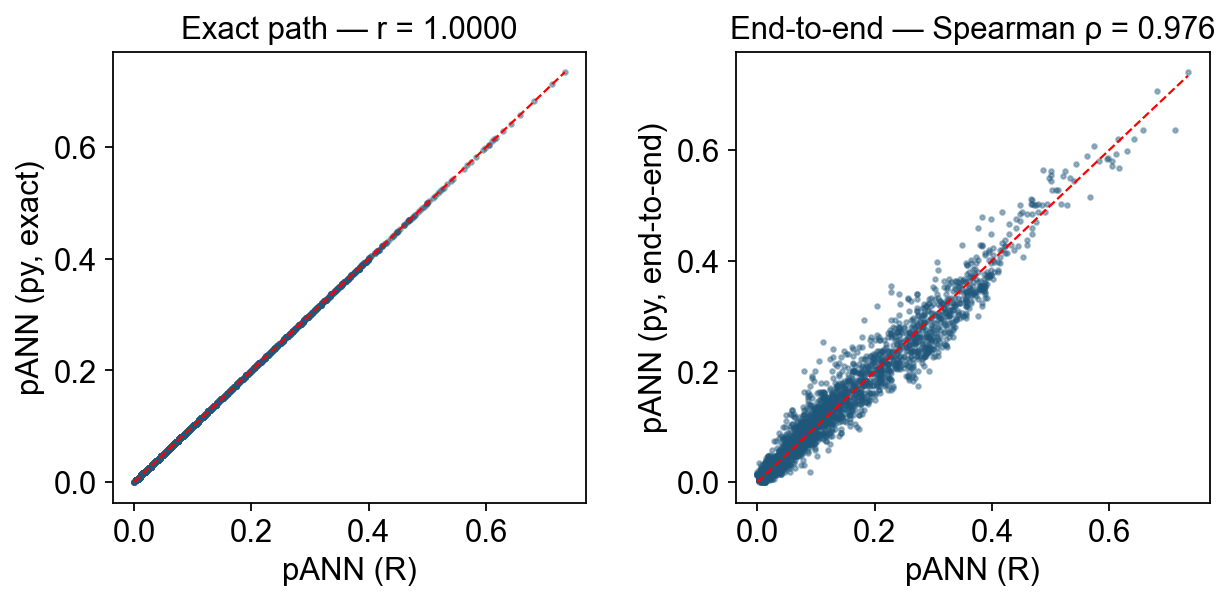

In [15]:
from scipy.stats import pearsonr, spearmanr
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Exact match
x = adata.obs['pANN_R'].values
y_ex = pd.Series(res_exact.pANN, index=r_df.index).reindex(adata.obs_names).values
axes[0].scatter(x, y_ex, s=4, alpha=0.4)
axes[0].plot([x.min(), x.max()], [x.min(), x.max()], 'r--', lw=1)
axes[0].set_xlabel('pANN (R)'); axes[0].set_ylabel('pANN (py, exact)')
r2 = pearsonr(x[np.isfinite(x) & np.isfinite(y_ex)], y_ex[np.isfinite(x) & np.isfinite(y_ex)])[0]
axes[0].set_title(f'Exact path — r = {r2:.4f}')

# End-to-end
y_py = adata.obs['pANN_py'].values
mask = np.isfinite(x) & np.isfinite(y_py)
axes[1].scatter(x[mask], y_py[mask], s=4, alpha=0.4)
axes[1].plot([x[mask].min(), x[mask].max()], [x[mask].min(), x[mask].max()], 'r--', lw=1)
axes[1].set_xlabel('pANN (R)'); axes[1].set_ylabel('pANN (py, end-to-end)')
rho = spearmanr(x[mask], y_py[mask])[0]
axes[1].set_title(f'End-to-end — Spearman ρ = {rho:.3f}')
plt.tight_layout(); plt.show()

## Summary

| Comparison | Expected | Observed |
|---|---|---|
| Python **exact** (fed R's PCA) vs R — pANN | element-for-element equal | check cell 3 output |
| Python **exact** vs R — classifications | 100% agreement | check cell 3 output |
| Python **end-to-end** vs R — doublet overlap | high (different PCAs reshuffle the tail) | see Venn / confusion |
| Per-cluster doublet rates | similar shape | see `ov.pl.cellproportion` panels |

Take-home: `doubletfinder_py` reproduces R's math exactly on the numerical kernel. The small residual disagreement you see in the end-to-end path comes entirely from differences in Seurat's vs. scikit-learn's PCA/variable-feature routines — not from the DoubletFinder algorithm itself.